In [1]:
# ! pip install -U bitsandbytes>=0.46.1 trl

In [2]:
import os
os.environ["ACCELERATE_MIXED_PRECISION"] = "no"

In [3]:
import torch
import wandb
from google.colab import userdata
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    set_seed
)
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model
from trl import SFTTrainer, SFTConfig

In [4]:
# Global Variables
BASE_MODEL = "Qwen/Qwen2.5-3B"

# Login to WandB
os.environ["WANDB_API_KEY"] = userdata.get('WANDB_API_KEY')
wandb.login()
wandb.init(project="Qwen_Tuning", name="Qwen2.5-3B-T4-Fix")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: essamhamza2004 (essamhamza2004-cairo-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, token=userdata.get('HF_TOKEN'))
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Official Qwen/ChatML Chat Template
tokenizer.chat_template = "{% for message in messages %}{{'<|im_start|>' + message['role'] + '\n' + message['content'] + '<|im_end|>' + '\n'}}{% endfor %}{% if add_generation_prompt %}{{ '<|im_start|>assistant\n' }}{% endif %}"

In [6]:
# Download and Format Dataset
dataset = load_dataset("mlabonne/FineTome-100k", split="train")

def format_conversation(row):
    messages = [{"role": "user" if m["from"] == "human" else "assistant", "content": m["value"]}
                for m in row["conversations"]]

    row["text"] = tokenizer.apply_chat_template(messages, tokenize=False)
    return row

print("Grabbing a 2,000 example subset...")
small_dataset = dataset.select(range(2000))

print("Formatting dataset to ChatML...")
formatted_dataset = small_dataset.map(format_conversation)

initial_split = formatted_dataset.train_test_split(test_size=0.1, seed=42)
test_val_split = initial_split['test'].train_test_split(test_size=0.5, seed=42)

final_dataset = DatasetDict({
    'train': initial_split['train'],
    'validation': test_val_split['train'],
    'test': test_val_split['test']
})

print(f"Dataset successfully prepared! Training size: {len(final_dataset['train'])} examples.")

README.md:   0%|          | 0.00/982 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Grabbing a 2,000 example subset...
Formatting dataset to ChatML...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset successfully prepared! Training size: 1800 examples.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Counting tokens for the 2000 examples...")

def count_tokens(row):
    tokens = tokenizer(row["text"], truncation=False, padding=False)
    return {"token_count": len(tokens["input_ids"])}

token_counted_dataset = formatted_dataset.map(count_tokens, num_proc=4)

token_counts = token_counted_dataset["token_count"]
percentiles = pd.Series(token_counts).describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99])

print("\n--- Token Length Statistics ---")
print(f"Average length: {int(percentiles['mean'])} tokens")
print(f"90% of data fits in: {int(percentiles['90%'])} tokens")
print(f"95% of data fits in: {int(percentiles['95%'])} tokens")
print(f"99% of data fits in: {int(percentiles['99%'])} tokens")
print(f"Maximum length: {int(percentiles['max'])} tokens")

Counting tokens for the 2000 examples...


Map (num_proc=4):   0%|          | 0/2000 [00:00<?, ? examples/s]


--- Token Length Statistics ---
Average length: 549 tokens
90% of data fits in: 975 tokens
95% of data fits in: 1264 tokens
99% of data fits in: 2097 tokens
Maximum length: 4653 tokens


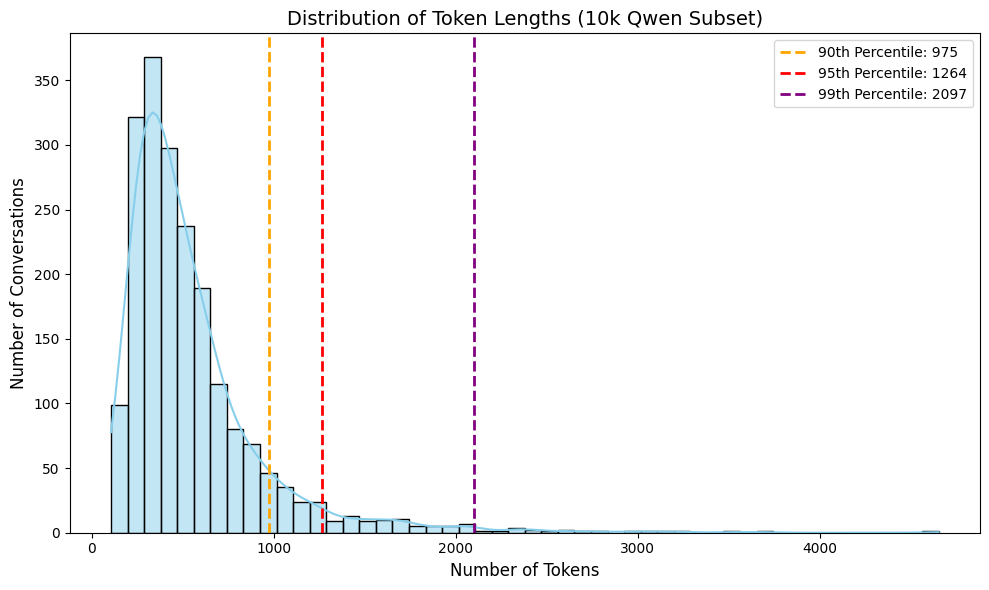

In [8]:
# 4. Plot the Distribution
plt.figure(figsize=(10, 6))
sns.histplot(token_counts, bins=50, color='skyblue', kde=True)

# Draw lines for our percentiles
plt.axvline(percentiles['90%'], color='orange', linestyle='dashed', linewidth=2, label=f"90th Percentile: {int(percentiles['90%'])}")
plt.axvline(percentiles['95%'], color='red', linestyle='dashed', linewidth=2, label=f"95th Percentile: {int(percentiles['95%'])}")
plt.axvline(percentiles['99%'], color='purple', linestyle='dashed', linewidth=2, label=f"99th Percentile: {int(percentiles['99%'])}")

plt.title('Distribution of Token Lengths (10k Qwen Subset)', fontsize=14)
plt.xlabel('Number of Tokens', fontsize=12)
plt.ylabel('Number of Conversations', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16, # Force FP16
    bnb_4bit_quant_type="nf4"
)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
    dtype=torch.float16,
    token=userdata.get('HF_TOKEN')
)

base_model.config.torch_dtype = torch.float16
base_model.config.use_cache = False

model = prepare_model_for_kbit_training(base_model)

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


In [10]:
# LoRA Configuration
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)

In [14]:
training_args = SFTConfig(
    output_dir="./Qwen2.5-3B-ChatML-LoRA-2k",

    # --- MEMORY MANAGEMENT ---
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    per_device_eval_batch_size=2,

    # --- LEARNING DYNAMICS ---
    learning_rate=2e-4,
    warmup_steps=20,
    num_train_epochs=3,

    # --- LOGGING & SAVING ---
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,

    # --- PRECISION & OPTIMIZER  ---
    fp16=False,
    bf16=False,
    optim="paged_adamw_8bit",

    # --- DATA FORMATTING ---
    dataset_text_field="text",
    max_length=1024,
    report_to="wandb"
)

In [15]:
# Initialize Trainer & Run
trainer = SFTTrainer(
    model=model,
    train_dataset=final_dataset["train"],
    eval_dataset=final_dataset["validation"],
    args=training_args,
    processing_class=tokenizer
)

In [17]:
print("Starting the fine-tuning process (Forced FP16)...")
trainer.train()

Starting the fine-tuning process (Forced FP16)...


Step,Training Loss,Validation Loss


KeyboardInterrupt: 

In [18]:
# Save the final adapter
trainer.model.save_pretrained("./final_lora_adapter")